# Why we neeed Autograd in Deep neural network

 > We need Autograd in deep neural networks because training requires gradients of the loss with respect to millions of model parameters. PyTorch Autograd automatically tracks the computational graph and uses reverse-mode automatic differentiation, based on the chain rule, to calculate these gradients during backpropagation. The optimizer then uses those gradients to update the weights.

## problem

**1. What is the problem?**

A neural network learns by adjusting its weights and biases.

For example:

$$ y = wx+b $$

The network makes a prediction, calculates the loss, and then needs to determine:

$$ \frac{\partial Loss}{\partial w} $$

and

$$ \frac{\partial Loss}{\partial b} $$

These derivatives are called gradients.

The gradients tell the network how to change its parameters to reduce the loss.

**2. How does a neural network learn?**

The basic learning process is:

Input

  ↓

Neural Network

  ↓

Prediction

  ↓

Loss

  ↓

Calculate Gradients

  ↓

Update Weights

  ↓

Repeat


Mathematically:

$$ W_{new}=W_{old}-\eta\frac{\partial L}{\partial W} $$

Where:

 * \(W\) = weight

* \(L\) = loss

* \(\eta\) = learning rate

* \(\frac{\partial L}{\partial W}\) = gradient

**3. Why is this difficult in Deep Neural Networks?**

A simple neural network might have a few parameters.

A deep neural network can have:


Layer 1 → thousands of parameters

Layer 2 → thousands of parameters

Layer 3 → thousands of parameters

Layer 4 → thousands of parameters

...

Modern neural networks can contain millions or even billions of parameters.

For every parameter, we need a gradient:

$$ \frac{\partial L}{\partial W_1} $$ $$ \frac{\partial L}{\partial W_2} $$ $$ \frac{\partial L}{\partial W_3} $$ $$ \vdots $$ $$ \frac{\partial L}{\partial W_n} $$

Doing this manually would be extremely complicated.

## Solution

Autograd is PyTorch's automatic differentiation engine.

It automatically calculates gradients for tensors that require gradients.

Simple definition

 > Autograd automatically calculates the gradients required to train a neural network.

In PyTorch:

 > loss.backward()

 triggers the backward computation.

**5. Autograd and the Computational Graph**

PyTorch tracks operations performed on tensors.

For example:

x → Linear → ReLU → Linear → Loss


  

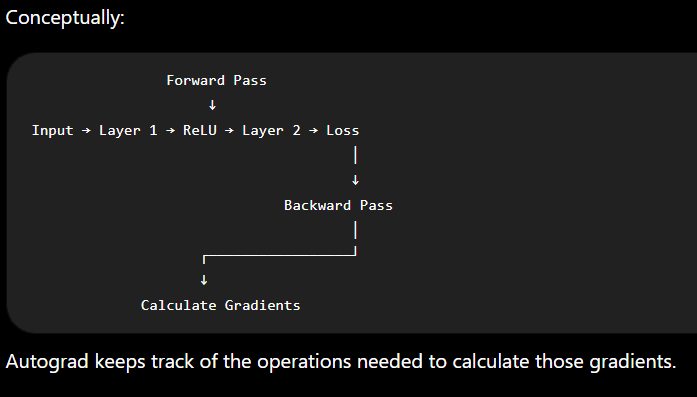

# Simple Math

y = x^2

dy/dx = 2 . x

## > Manual differentiation

In [1]:
def dy_dx(x):
  return 2*x

dy_dx(5)

10

direct differentiation of : x^ 2

## > Autograd differentiation

In [17]:
import torch

In [18]:
x = torch.tensor(6.0 , requires_grad= True)

y = x**2

In [19]:
x

tensor(6., requires_grad=True)

In [20]:
y

tensor(36., grad_fn=<PowBackward0>)

In [21]:
y.backward() #Calculate differentiation

In [22]:
x.grad

tensor(12.)

## Manual differentiation

chain Rule

y = x ^ 2      ;  ----> dy/dx = 2 . x

z = sin(y)      ; -----> dz / dy = cos . y

> dz/dx = dz/dy  . dy / dx

In [23]:
import math

def dz_dx(x):
  return 2 * x * math.cos(x ** 2)

dz_dx(4)

-7.661275842587077

## Autograd differentiation

In [27]:
x = torch.tensor(4.0 , requires_grad= True)  # Value of X - converted into tensor

In [28]:
y = x ** 2     # Define y function

In [29]:
z = torch.sin(y)  # Define Z function

In [30]:
print(x)
print(y)
print(z)

tensor(4., requires_grad=True)
tensor(16., grad_fn=<PowBackward0>)
tensor(-0.2879, grad_fn=<SinBackward0>)


chain Rule

In [31]:
z.backward() # Calculate Chain differentiation of complex function

In [32]:
x.grad

tensor(-7.6613)

> This is the result , derivation of x value.

# Manual Gradient and Loss Calculation

In [35]:
import  torch

x = torch.tensor(6.7)
y = torch.tensor(0.0)

w = torch.tensor(1.0) # Weight
b = torch.tensor(0.0) # Bias

## Loss Calculation

In [36]:
# Binary Cross-Entropy Loss for scalar
def binary_cross_entropy_loss(prediction, target):
    epsilon = 1e-8  # To prevent log(0)
    prediction = torch.clamp(prediction, epsilon, 1 - epsilon)
    return -(target * torch.log(prediction) + (1 - target) * torch.log(1 - prediction))

## Forward Pass

In [37]:
# Forward pass
z = w * x + b  # Weighted sum (linear part)
y_pred = torch.sigmoid(z)  # Predicted probability

# Compute binary cross-entropy loss
loss = binary_cross_entropy_loss(y_pred, y)

In [38]:
loss

tensor(6.7012)

## manual derivatives

In [39]:
# Derivatives:
# 1. dL/d(y_pred): Loss with respect to the prediction (y_pred)
dloss_dy_pred = (y_pred - y)/(y_pred*(1-y_pred))

# 2. dy_pred/dz: Prediction (y_pred) with respect to z (sigmoid derivative)
dy_pred_dz = y_pred * (1 - y_pred)

# 3. dz/dw and dz/db: z with respect to w and b
dz_dw = x  # dz/dw = x
dz_db = 1  # dz/db = 1 (bias contributes directly to z)

dL_dw = dloss_dy_pred * dy_pred_dz * dz_dw
dL_db = dloss_dy_pred * dy_pred_dz * dz_db

In [40]:
print(f"Manual Gradient of loss w.r.t weight (dw): {dL_dw}")
print(f"Manual Gradient of loss w.r.t bias (db): {dL_db}")

Manual Gradient of loss w.r.t weight (dw): 6.691762447357178
Manual Gradient of loss w.r.t bias (db): 0.998770534992218


# Autograd Calculation

In [41]:
x = torch.tensor(6.7)
y = torch.tensor(0.0)

w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

In [42]:
print(x)
print(y)
print(w)
print(b)

tensor(6.7000)
tensor(0.)
tensor(1., requires_grad=True)
tensor(0., requires_grad=True)


## Forward Pass

In [43]:
z = w*x + b
z

tensor(6.7000, grad_fn=<AddBackward0>)

In [44]:
y_pred = torch.sigmoid(z)
y_pred

tensor(0.9988, grad_fn=<SigmoidBackward0>)

## Loss Calculation

In [45]:
loss = binary_cross_entropy_loss(y_pred, y)
loss

tensor(6.7012, grad_fn=<NegBackward0>)

In [46]:
loss.backward()

In [47]:
print(w.grad)
print(b.grad)

tensor(6.6918)
tensor(0.9988)


# Conclusion

Observe the manual and the Autograd